In [1]:
!pip install openpyxl -q

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
mpl.rcParams["font.family"] = "DejaVu Serif"
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["axes.labelsize"] = 13
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.fontsize"] = 11
mpl.rcParams["figure.titlesize"] = 18

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.linewidth"] = 1.2
mpl.rcParams["grid.alpha"] = 0.25

COLORS = {
    "burgundy": "#7A1F3D",
    "gold": "#C9A227",
    "forest": "#2E5E4E",
    "plum": "#5A3E6B",
    "coral": "#D96C5F",
    "sand": "#D8C3A5",
    "charcoal": "#2F2F2F",
    "sage": "#9CAF88"
}

def beautify_plot(ax, title, xlabel="", ylabel="", facecolor="#FAF7F2"):
    ax.set_title(title, pad=14, color="#2F2F2F", weight="bold")
    ax.set_xlabel(xlabel, color="#2F2F2F")
    ax.set_ylabel(ylabel, color="#2F2F2F")
    ax.set_facecolor(facecolor)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.25)
    return ax

In [4]:
FILE_PATHS = [
    "mango_full_comparison_by_category (1).7csv",
    "mango_full_comparison_by_category 2.xlsx",
    "mango_full_comparison_by_category.3csv.xlsx",
    "mango_full_comparison_by_category.4csv",
    "mango_full_comparison_by_category.7csv",
    "mango_full_comparison_by_category.8csv",
    "mango_full_comparison_by_category.9csv",
    "mango_full_comparison_by_category.c5sv",
    "mango_full_comparison_by_category6.csv"
]

In [5]:
def load_any_table(path):
    lower = path.lower()
    if lower.endswith(".xlsx"):
        return pd.read_excel(path)
    else:
        return pd.read_csv(path)

dfs = []

for path in FILE_PATHS:
    if not os.path.exists(path):
        print(f"Missing file: {path}")
        continue

    try:
        temp = load_any_table(path)
        temp["uploaded_file_name"] = path
        dfs.append(temp)
        print(f"Loaded: {path} | shape={temp.shape}")
    except Exception as e:
        print(f"Could not load {path}: {e}")

full_df = pd.concat(dfs, ignore_index=True)

print("\nCombined shape:", full_df.shape)
print("\nColumns:")
print(full_df.columns.tolist())

full_df.head()

Loaded: mango_full_comparison_by_category (1).7csv | shape=(76, 32)
Loaded: mango_full_comparison_by_category 2.xlsx | shape=(76, 32)
Loaded: mango_full_comparison_by_category.3csv.xlsx | shape=(76, 32)
Loaded: mango_full_comparison_by_category.4csv | shape=(75, 32)
Loaded: mango_full_comparison_by_category.7csv | shape=(76, 32)
Loaded: mango_full_comparison_by_category.8csv | shape=(76, 32)
Loaded: mango_full_comparison_by_category.9csv | shape=(75, 32)
Loaded: mango_full_comparison_by_category.c5sv | shape=(76, 32)
Loaded: mango_full_comparison_by_category6.csv | shape=(76, 32)

Combined shape: (682, 32)

Columns:
['Product_ID', 'Segment', 'Source File', 'Specific_Category', 'US_url', 'IN_url', 'name', 'colour_from_title', 'US_price_current_usd', 'US_price_original_usd', 'US_discount_pct_display', 'US_discount_pct_calc', 'US_on_sale', 'IN_price_current_inr', 'IN_price_original_inr', 'IN_price_current_usd', 'IN_price_original_usd', 'IN_discount_pct_display', 'IN_discount_pct_calc', 'I

,Product_ID,Segment,Source File,Specific_Category,US_url,IN_url,name,colour_from_title,US_price_current_usd,US_price_original_usd,...,made_in,US_detail_selector,US_composition_selector,IN_detail_selector,IN_composition_selector,row_collected_at_local,row_collected_at_utc,fx_rate_live_usd_inr,fx_rate_timestamp_utc,uploaded_file_name
0,17001208,Women,comparison_jeans,Women_jeans,https://shop.mango.com/us/en/p/women/jeans/wid...,https://shop.mango.com/in/en/p/women/jeans/wid...,High-rise wide leg jeans with pockets - Women ...,NaN,79.99,NaN,...,Bangladesh\nDye,text=Details,NaN,text=DETAILS,NaN,2026-04-03T11:51:18.169331-04:00,2026-04-03T15:51:18.169405+00:00,92.69866,2026-04-03T15:49:00+00:00,mango_full_comparison_by_category (1).7csv
1,17001212,Women,comparison_jeans,Women_jeans,https://shop.mango.com/us/en/p/women/jeans/wid...,https://shop.mango.com/in/en/p/women/jeans/wid...,Wide leg pleated jeans - Women | MANGO USA,NaN,69.99,NaN,...,Bangladesh\nDye,text=DETAILS,NaN,text=DETAILS,NaN,2026-04-03T11:52:03.874248-04:00,2026-04-03T15:52:03.874284+00:00,92.70896,2026-04-03T15:50:00+00:00,mango_full_comparison_by_category (1).7csv
2,17007792,Women,comparison_knitwear,Women_knitwear,https://shop.mango.com/us/en/p/women/sweaters-...,https://shop.mango.com/in/en/p/women/sweaters-...,Medium-knit sweater - Women | MANGO USA,NaN,69.99,NaN,...,China\nDye,text=DETAILS,NaN,text=DETAILS,NaN,2026-04-03T11:52:45.533242-04:00,2026-04-03T15:52:45.533268+00:00,92.69894,2026-04-03T15:51:00+00:00,mango_full_comparison_by_category (1).7csv
3,17007908,Men,comparison_men_knitwear,Men_men_knitwear,https://shop.mango.com/us/en/p/men/sweaters-an...,https://shop.mango.com/in/en/p/men/sweaters-an...,Fine-knit wool-blend sweater - Men | MANGO USA,NaN,99.99,NaN,...,China\nDye,text=DETAILS,NaN,text=DETAILS,NaN,2026-04-03T11:53:27.800167-04:00,2026-04-03T15:53:27.800188+00:00,92.85181,2026-04-03T15:52:00+00:00,mango_full_comparison_by_category (1).7csv
4,17011170,Women,comparison_dresses,Women_dresses,https://shop.mango.com/us/en/p/women/dresses-a...,https://shop.mango.com/in/en/p/women/dresses-a...,Long balloon dress - Women | MANGO USA,NaN,89.99,NaN,...,China\nDye,text=DETAILS,NaN,text=DETAILS,NaN,2026-04-03T11:54:09.990403-04:00,2026-04-03T15:54:09.990447+00:00,92.85181,2026-04-03T15:52:00+00:00,mango_full_comparison_by_category (1).7csv


In [7]:
df = full_df.copy()

numeric_cols = [
    "US_price_current_usd",
    "US_price_original_usd",
    "US_discount_pct_display",
    "US_discount_pct_calc",
    "IN_price_current_inr",
    "IN_price_original_inr",
    "IN_price_current_usd",
    "IN_price_original_usd",
    "IN_discount_pct_display",
    "IN_discount_pct_calc",
    "Savings_USD",
    "fx_rate_live_usd_inr"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

bool_cols = ["US_on_sale", "IN_on_sale"]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype("boolean")

if "row_collected_at_utc" in df.columns:
    df["row_collected_at_utc"] = pd.to_datetime(df["row_collected_at_utc"], errors="coerce")

if "fx_rate_timestamp_utc" in df.columns:
    df["fx_rate_timestamp_utc"] = pd.to_datetime(df["fx_rate_timestamp_utc"], errors="coerce")

df = df.dropna(subset=["US_price_current_usd"])
df = df[df["US_price_current_usd"] > 0].copy()

print("Rows after cleaning:", len(df))
df.head()

Rows after cleaning: 682


,Product_ID,Segment,Source File,Specific_Category,US_url,IN_url,name,colour_from_title,US_price_current_usd,US_price_original_usd,...,made_in,US_detail_selector,US_composition_selector,IN_detail_selector,IN_composition_selector,row_collected_at_local,row_collected_at_utc,fx_rate_live_usd_inr,fx_rate_timestamp_utc,uploaded_file_name
0,17001208,Women,comparison_jeans,Women_jeans,https://shop.mango.com/us/en/p/women/jeans/wid...,https://shop.mango.com/in/en/p/women/jeans/wid...,High-rise wide leg jeans with pockets - Women ...,NaN,79.99,NaN,...,Bangladesh\nDye,text=Details,NaN,text=DETAILS,NaN,2026-04-03T11:51:18.169331-04:00,2026-04-03 15:51:18.169405+00:00,92.69866,2026-04-03 15:49:00+00:00,mango_full_comparison_by_category (1).7csv
1,17001212,Women,comparison_jeans,Women_jeans,https://shop.mango.com/us/en/p/women/jeans/wid...,https://shop.mango.com/in/en/p/women/jeans/wid...,Wide leg pleated jeans - Women | MANGO USA,NaN,69.99,NaN,...,Bangladesh\nDye,text=DETAILS,NaN,text=DETAILS,NaN,2026-04-03T11:52:03.874248-04:00,2026-04-03 15:52:03.874284+00:00,92.70896,2026-04-03 15:50:00+00:00,mango_full_comparison_by_category (1).7csv
2,17007792,Women,comparison_knitwear,Women_knitwear,https://shop.mango.com/us/en/p/women/sweaters-...,https://shop.mango.com/in/en/p/women/sweaters-...,Medium-knit sweater - Women | MANGO USA,NaN,69.99,NaN,...,China\nDye,text=DETAILS,NaN,text=DETAILS,NaN,2026-04-03T11:52:45.533242-04:00,2026-04-03 15:52:45.533268+00:00,92.69894,2026-04-03 15:51:00+00:00,mango_full_comparison_by_category (1).7csv
3,17007908,Men,comparison_men_knitwear,Men_men_knitwear,https://shop.mango.com/us/en/p/men/sweaters-an...,https://shop.mango.com/in/en/p/men/sweaters-an...,Fine-knit wool-blend sweater - Men | MANGO USA,NaN,99.99,NaN,...,China\nDye,text=DETAILS,NaN,text=DETAILS,NaN,2026-04-03T11:53:27.800167-04:00,2026-04-03 15:53:27.800188+00:00,92.85181,2026-04-03 15:52:00+00:00,mango_full_comparison_by_category (1).7csv
4,17011170,Women,comparison_dresses,Women_dresses,https://shop.mango.com/us/en/p/women/dresses-a...,https://shop.mango.com/in/en/p/women/dresses-a...,Long balloon dress - Women | MANGO USA,NaN,89.99,NaN,...,China\nDye,text=DETAILS,NaN,text=DETAILS,NaN,2026-04-03T11:54:09.990403-04:00,2026-04-03 15:54:09.990447+00:00,92.85181,2026-04-03 15:52:00+00:00,mango_full_comparison_by_category (1).7csv


In [8]:
def contains_word(text, word):
    if pd.isna(text):
        return 0
    text = str(text).lower()
    return int(word in text)

material_words = [
    "cotton", "linen", "wool", "leather", "silk", "polyester",
    "viscose", "denim", "nylon", "cashmere", "acrylic", "lyocell"
]

for word in material_words:
    if "materials_text" in df.columns:
        df[f"mat_{word}"] = df["materials_text"].apply(lambda x: contains_word(x, word))
    else:
        df[f"mat_{word}"] = 0

name_words = [
    "dress", "jeans", "blazer", "shirt", "trousers", "jacket",
    "sweater", "skirt", "top", "tailored", "wide-leg", "straight",
    "cropped", "oversized", "midi", "maxi", "ribbed", "cargo",
    "structured", "knit", "pleated", "satin", "embroidered"
]

for word in name_words:
    if "name" in df.columns:
        df[f"name_{word.replace('-', '_')}"] = df["name"].apply(lambda x: contains_word(x, word))
    else:
        df[f"name_{word.replace('-', '_')}"] = 0

if "row_collected_at_utc" in df.columns:
    df["collection_hour"] = df["row_collected_at_utc"].dt.hour
    df["collection_dayofweek"] = df["row_collected_at_utc"].dt.dayofweek
else:
    df["collection_hour"] = np.nan
    df["collection_dayofweek"] = np.nan

if "IN_price_original_inr" in df.columns:
    df["log_in_original"] = np.log1p(pd.to_numeric(df["IN_price_original_inr"], errors="coerce"))
else:
    df["log_in_original"] = np.nan

if "IN_price_current_inr" in df.columns:
    df["log_in_current"] = np.log1p(pd.to_numeric(df["IN_price_current_inr"], errors="coerce"))
else:
    df["log_in_current"] = np.nan

df["log_in_original"] = df["log_in_original"].fillna(df["log_in_current"])

df.head()

,Product_ID,Segment,Source File,Specific_Category,US_url,IN_url,name,colour_from_title,US_price_current_usd,US_price_original_usd,...,name_cargo,name_structured,name_knit,name_pleated,name_satin,name_embroidered,collection_hour,collection_dayofweek,log_in_original,log_in_current
0,17001208,Women,comparison_jeans,Women_jeans,https://shop.mango.com/us/en/p/women/jeans/wid...,https://shop.mango.com/in/en/p/women/jeans/wid...,High-rise wide leg jeans with pockets - Women ...,NaN,79.99,NaN,...,0,0,0,0,0,0,15,4,8.364275,8.364275
1,17001212,Women,comparison_jeans,Women_jeans,https://shop.mango.com/us/en/p/women/jeans/wid...,https://shop.mango.com/in/en/p/women/jeans/wid...,Wide leg pleated jeans - Women | MANGO USA,NaN,69.99,NaN,...,0,0,0,1,0,0,15,4,8.291797,8.291797
2,17007792,Women,comparison_knitwear,Women_knitwear,https://shop.mango.com/us/en/p/women/sweaters-...,https://shop.mango.com/in/en/p/women/sweaters-...,Medium-knit sweater - Women | MANGO USA,NaN,69.99,NaN,...,0,0,1,0,0,0,15,4,8.340695,8.340695
3,17007908,Men,comparison_men_knitwear,Men_men_knitwear,https://shop.mango.com/us/en/p/men/sweaters-an...,https://shop.mango.com/in/en/p/men/sweaters-an...,Fine-knit wool-blend sweater - Men | MANGO USA,NaN,99.99,NaN,...,0,0,1,0,0,0,15,4,8.746875,8.746875
4,17011170,Women,comparison_dresses,Women_dresses,https://shop.mango.com/us/en/p/women/dresses-a...,https://shop.mango.com/in/en/p/women/dresses-a...,Long balloon dress - Women | MANGO USA,NaN,89.99,NaN,...,0,0,0,0,0,0,15,4,8.515392,8.515392


In [9]:
target = "US_price_current_usd"

categorical_features = [
    "Segment",
    "Specific_Category",
    "colour_from_title",
    "made_in",
    "uploaded_file_name"
]

numeric_features = [
    "IN_price_current_inr",
    "IN_price_original_inr",
    "IN_discount_pct_display",
    "IN_discount_pct_calc",
    "fx_rate_live_usd_inr",
    "collection_hour",
    "collection_dayofweek",
    "log_in_original",
    "log_in_current"
]

boolean_features = [
    "US_on_sale",
    "IN_on_sale"
]

material_features = [col for col in df.columns if col.startswith("mat_")]
name_features = [col for col in df.columns if col.startswith("name_")]

all_features = categorical_features + numeric_features + boolean_features + material_features + name_features
existing_features = [col for col in all_features if col in df.columns]

model_df = df.dropna(subset=[target]).copy()

X = model_df[existing_features].copy()
y = model_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:")
print(existing_features)

X shape: (682, 51)
y shape: (682,)

Features used:
['Segment', 'Specific_Category', 'colour_from_title', 'made_in', 'uploaded_file_name', 'IN_price_current_inr', 'IN_price_original_inr', 'IN_discount_pct_display', 'IN_discount_pct_calc', 'fx_rate_live_usd_inr', 'collection_hour', 'collection_dayofweek', 'log_in_original', 'log_in_current', 'US_on_sale', 'IN_on_sale', 'mat_cotton', 'mat_linen', 'mat_wool', 'mat_leather', 'mat_silk', 'mat_polyester', 'mat_viscose', 'mat_denim', 'mat_nylon', 'mat_cashmere', 'mat_acrylic', 'mat_lyocell', 'name_dress', 'name_jeans', 'name_blazer', 'name_shirt', 'name_trousers', 'name_jacket', 'name_sweater', 'name_skirt', 'name_top', 'name_tailored', 'name_wide_leg', 'name_straight', 'name_cropped', 'name_oversized', 'name_midi', 'name_maxi', 'name_ribbed', 'name_cargo', 'name_structured', 'name_knit', 'name_pleated', 'name_satin', 'name_embroidered']


In [10]:
 X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

Train rows: 545
Test rows: 137


In [11]:
categorical_in_X = [col for col in categorical_features if col in X.columns]
numeric_in_X = [col for col in (numeric_features + boolean_features + material_features + name_features) if col in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_in_X
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_in_X
        )
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained.")

Model trained.


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['IN_price_original_inr' 'IN_discount_pct_display' 'IN_discount_pct_calc']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['colour_from_title']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['IN_price_original_inr' 'IN_discount_pct_display' 'IN_discount_pct_calc']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['colour_fr

In [12]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R^2 :", round(r2, 4))

MAE : 4.4004
RMSE: 5.9418
R^2 : 0.9903


In [13]:
results = X_test.copy()
results["actual_us_price"] = y_test.values
results["predicted_us_price"] = y_pred
results["pricing_surprise"] = results["actual_us_price"] - results["predicted_us_price"]
results["abs_pricing_surprise"] = results["pricing_surprise"].abs()

id_cols = ["Product_ID", "name", "Specific_Category", "Segment", "colour_from_title", "made_in"]
for col in id_cols:
    if col in model_df.columns:
        results[col] = model_df.loc[X_test.index, col].values

results = results.sort_values("abs_pricing_surprise", ascending=False)

results.head(10)

,Segment,Specific_Category,colour_from_title,made_in,uploaded_file_name,IN_price_current_inr,IN_price_original_inr,IN_discount_pct_display,IN_discount_pct_calc,fx_rate_live_usd_inr,...,name_knit,name_pleated,name_satin,name_embroidered,actual_us_price,predicted_us_price,pricing_surprise,abs_pricing_surprise,Product_ID,name
599,Men,Men_men_outerwear,NaN,China\nDye,mango_full_comparison_by_category.c5sv,11990.0,NaN,NaN,NaN,92.97200,...,0,0,0,0,139.99,154.547184,-14.557184,14.557184,27091175,Short water-repellent puffer jacket - Men | MA...
145,Men,Men_men_outerwear,NaN,China\nDye,mango_full_comparison_by_category 2.xlsx,11990.0,NaN,NaN,NaN,93.23737,...,0,0,0,0,139.99,154.214865,-14.224865,14.224865,27091175,Short water-repellent puffer jacket - Men | MA...
523,Men,Men_men_outerwear,NaN,China\nDye,mango_full_comparison_by_category.9csv,11990.0,NaN,NaN,NaN,92.89496,...,0,0,0,0,139.99,154.129026,-14.139026,14.139026,27091175,Short water-repellent puffer jacket - Men | MA...
296,Men,Men_men_outerwear,NaN,China\nDye,mango_full_comparison_by_category.4csv,11990.0,NaN,NaN,NaN,92.92955,...,0,0,0,0,139.99,154.072450,-14.082450,14.082450,27091175,Short water-repellent puffer jacket - Men | MA...
69,Men,Men_men_outerwear,NaN,China\nDye,mango_full_comparison_by_category (1).7csv,11990.0,NaN,NaN,NaN,92.72197,...,0,0,0,0,139.99,153.916175,-13.926175,13.926175,27091175,Short water-repellent puffer jacket - Men | MA...
601,Men,Men_men_shirts,NaN,China\nDye,mango_full_comparison_by_category.c5sv,4990.0,NaN,NaN,NaN,92.96043,...,0,0,0,0,79.99,92.847514,-12.857514,12.857514,27091261,100% cotton dress shirt - Men | MANGO USA
571,Women,Women_dresses,NaN,Vietnam\nDye,mango_full_comparison_by_category.c5sv,5990.0,NaN,NaN,NaN,92.96892,...,0,0,0,0,99.99,112.416371,-12.426371,12.426371,27051199,Asymmetrical dress with scarf - Women | MANGO USA
677,Men,Men_men_shirts,NaN,China\nDye,mango_full_comparison_by_category6.csv,4990.0,NaN,NaN,NaN,92.67707,...,0,0,0,0,79.99,92.053088,-12.063088,12.063088,27091261,100% cotton dress shirt - Men | MANGO USA
90,Women,Women_dresses,NaN,Vietnam\nDye,mango_full_comparison_by_category 2.xlsx,7090.0,NaN,NaN,NaN,93.57059,...,0,0,0,0,139.99,127.947105,12.042895,12.042895,17079111,Draped dress with metallic detail - Women | MA...
223,Men,Men_men_shirts,NaN,China\nDye,mango_full_comparison_by_category.3csv.xlsx,4990.0,NaN,NaN,NaN,92.79808,...,0,0,0,0,79.99,92.020348,-12.030348,12.030348,27091261,100% cotton dress shirt - Men | MANGO USA


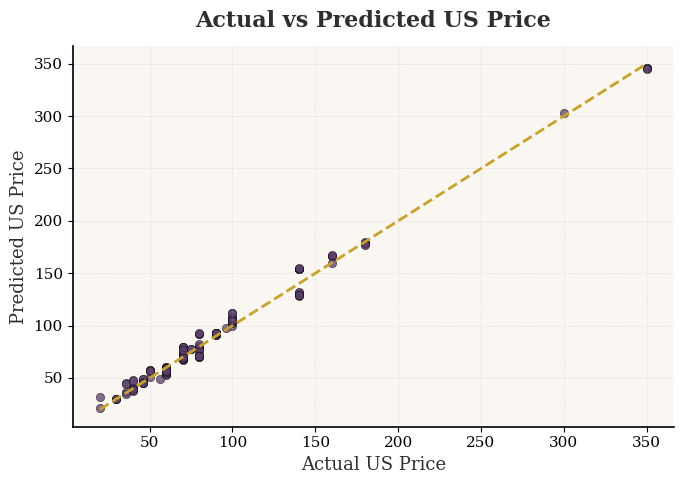

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, color=COLORS["plum"], alpha=0.75, edgecolor="black", linewidth=0.4)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
ax.plot([min_val, max_val], [min_val, max_val], color=COLORS["gold"], linestyle="--", linewidth=2)

beautify_plot(ax, "Actual vs Predicted US Price", "Actual US Price", "Predicted US Price")
plt.tight_layout()
plt.show()

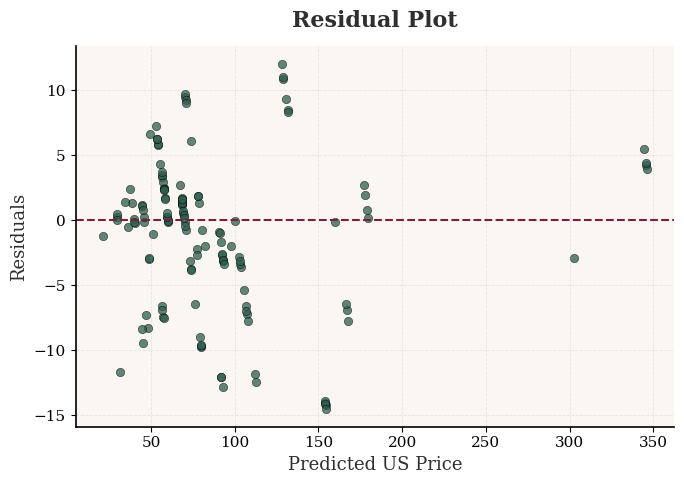

In [15]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, color=COLORS["forest"], alpha=0.75, edgecolor="black", linewidth=0.4)
ax.axhline(0, color=COLORS["burgundy"], linestyle="--", linewidth=1.5)

beautify_plot(ax, "Residual Plot", "Predicted US Price", "Residuals")
plt.tight_layout()
plt.show()

In [1]:
top_over = results.sort_values("pricing_surprise", ascending=False).head(500)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_over["name"].astype(str), top_over["pricing_surprise"], color=COLORS["burgundy"], edgecolor="black")
ax.invert_yaxis()

beautify_plot(ax, "Top Products Priced Higher Than Expected", "Pricing Surprise", "Product")
plt.tight_layout()
plt.show()

top_over[["Product_ID", "name", "Specific_Category", "actual_us_price", "predicted_us_price", "pricing_surprise"]]

NameError: name 'results' is not defined

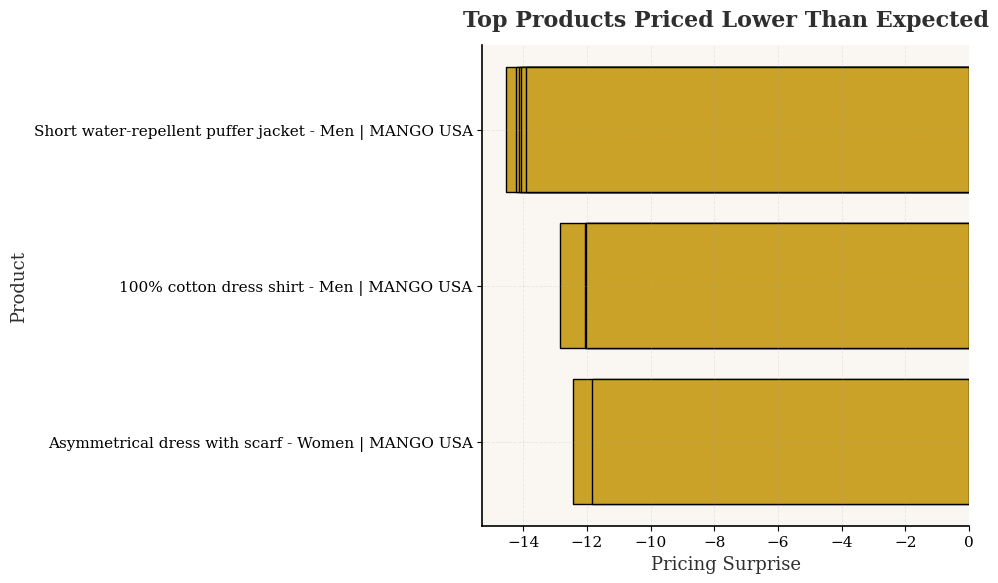

,Product_ID,name,Specific_Category,actual_us_price,predicted_us_price,pricing_surprise
599,27091175,Short water-repellent puffer jacket - Men | MA...,Men_men_outerwear,139.99,154.547184,-14.557184
145,27091175,Short water-repellent puffer jacket - Men | MA...,Men_men_outerwear,139.99,154.214865,-14.224865
523,27091175,Short water-repellent puffer jacket - Men | MA...,Men_men_outerwear,139.99,154.129026,-14.139026
296,27091175,Short water-repellent puffer jacket - Men | MA...,Men_men_outerwear,139.99,154.072450,-14.082450
69,27091175,Short water-repellent puffer jacket - Men | MA...,Men_men_outerwear,139.99,153.916175,-13.926175
601,27091261,100% cotton dress shirt - Men | MANGO USA,Men_men_shirts,79.99,92.847514,-12.857514
571,27051199,Asymmetrical dress with scarf - Women | MANGO USA,Women_dresses,99.99,112.416371,-12.426371
677,27091261,100% cotton dress shirt - Men | MANGO USA,Men_men_shirts,79.99,92.053088,-12.063088
223,27091261,100% cotton dress shirt - Men | MANGO USA,Men_men_shirts,79.99,92.020348,-12.030348
41,27051199,Asymmetrical dress with scarf - Women | MANGO USA,Women_dresses,99.99,111.836073,-11.846073


In [17]:
top_under = results.sort_values("pricing_surprise", ascending=True).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_under["name"].astype(str), top_under["pricing_surprise"], color=COLORS["gold"], edgecolor="black")
ax.invert_yaxis()

beautify_plot(ax, "Top Products Priced Lower Than Expected", "Pricing Surprise", "Product")
plt.tight_layout()
plt.show()

top_under[["Product_ID", "name", "Specific_Category", "actual_us_price", "predicted_us_price", "pricing_surprise"]]

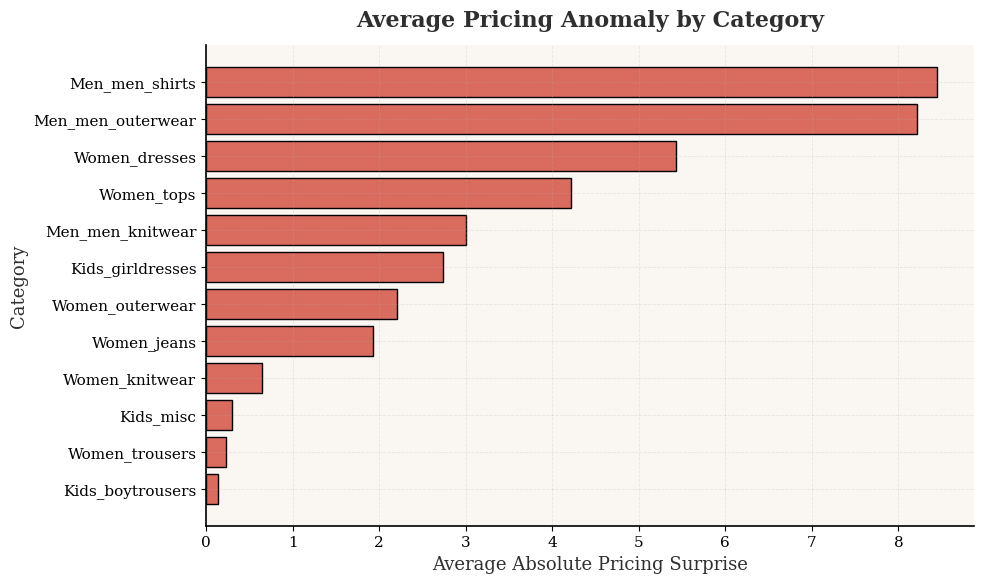

In [18]:
if "Specific_Category" in results.columns:
    cat_anomaly = (
        results.groupby("Specific_Category", as_index=False)["abs_pricing_surprise"]
        .mean()
        .sort_values("abs_pricing_surprise", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(cat_anomaly["Specific_Category"], cat_anomaly["abs_pricing_surprise"], color=COLORS["coral"], edgecolor="black")
    ax.invert_yaxis()

    beautify_plot(ax, "Average Pricing Anomaly by Category", "Average Absolute Pricing Surprise", "Category")
    plt.tight_layout()
    plt.show()

    cat_anomaly.head(20)

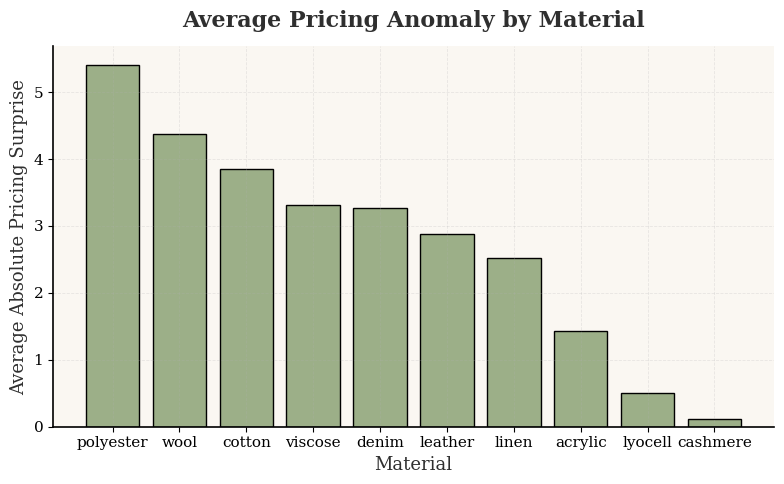

,material,avg_abs_pricing_surprise,count
4,polyester,5.411752,68
2,wool,4.371224,30
0,cotton,3.856580,83
5,viscose,3.318650,39
6,denim,3.273106,3
3,leather,2.874570,1
1,linen,2.519834,15
8,acrylic,1.426801,13
9,lyocell,0.497441,2
7,cashmere,0.110961,1


In [19]:
material_summary = []

for word in material_words:
    col = f"mat_{word}"
    subset = results[results[col] == 1]
    if len(subset) > 0:
        material_summary.append({
            "material": word,
            "avg_abs_pricing_surprise": subset["abs_pricing_surprise"].mean(),
            "count": len(subset)
        })

material_summary = pd.DataFrame(material_summary).sort_values("avg_abs_pricing_surprise", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(material_summary["material"], material_summary["avg_abs_pricing_surprise"], color=COLORS["sage"], edgecolor="black")

beautify_plot(ax, "Average Pricing Anomaly by Material", "Material", "Average Absolute Pricing Surprise")
plt.tight_layout()
plt.show()

material_summary

In [20]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

print("Top positive coefficients:")
display(coef_df.head(15))

print("Top negative coefficients:")
display(coef_df.tail(15))

Top positive coefficients:


,feature,coefficient
0,num__IN_price_current_inr,47.782321
64,cat__made_in_Egypt\nDye,15.662945
55,cat__Specific_Category_Women_outerwear,10.724954
59,cat__made_in_Bangladesh\nDye,10.320405
57,cat__Specific_Category_Women_trousers,9.981121
51,cat__Specific_Category_Men_men_shirts,8.787665
68,cat__made_in_Pakistan\nDye,8.079158
45,cat__Segment_Women,6.374165
11,num__mat_leather,5.370806
65,cat__made_in_India\nDye,4.931634


Top negative coefficients:


,feature,coefficient
9,num__mat_linen,-2.816771
43,cat__Segment_Kids,-3.053013
21,num__name_jeans,-3.308086
44,cat__Segment_Men,-3.321152
3,num__collection_dayofweek,-3.698276
76,cat__uploaded_file_name_mango_full_comparison_...,-3.779791
46,cat__Specific_Category_Kids_boytrousers,-4.146399
67,cat__made_in_Morocco\nDye,-5.681684
17,num__mat_cashmere,-8.296787
75,cat__uploaded_file_name_mango_full_comparison_...,-8.610552
